# Portfolio Budget Optimization — Multi-Brand Budget Allocation

**PyMC-Marketing optimizes one model at a time. But what if you manage multiple brands?** Optimizing each brand independently leaves money on the table — the marginal dollar might be worth more in Brand B than Brand A.

This notebook builds a **portfolio budget optimizer from scratch** that allocates budget across multiple brands and channels simultaneously, using the same marginal return equalization principle that drives efficient financial portfolios.

### What you'll learn:

1. **Why portfolio optimization beats independent optimization** — with a worked example
2. **The math** — marginal return equalization across brands and channels
3. **Building response curves** — tanh saturation for 3 brands × 3 channels
4. **Single-brand optimizer** — scipy.optimize with SLSQP for one brand
5. **PyMC-Marketing's BudgetOptimizer** — fitting a real MMM and using the production-ready optimizer
6. **Portfolio optimizer** — extending to all brands with a shared budget
7. **Risk adjustment (γ)** — mean-variance optimization and efficient frontiers
8. **Trademark channels** — cross-brand spillover ("ghost curves")
9. **Channel constraints** — min/max bounds per channel
10. **Results comparison** — independent vs. portfolio total revenue lift

---


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from scipy import optimize
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 11, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.labelsize': 12, 'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': '#FAFBFC', 'axes.facecolor': '#FAFBFC',
    'axes.edgecolor': '#D0D7DE', 'axes.grid': True, 'grid.alpha': 0.3,
    'grid.color': '#D0D7DE', 'legend.framealpha': 0.9, 'legend.edgecolor': '#D0D7DE',
})
COLORS = ['#2563EB', '#F97316', '#10B981', '#EF4444', '#8B5CF6', '#EC4899']

import os
os.makedirs('images', exist_ok=True)

# Load the multi-brand dataset for context
df = pd.read_csv('data/sample_multi_brand.csv', parse_dates=['date'])
print(f'Loaded {len(df)} rows across {df["brand"].nunique()} brands')
print(f'Brands: {sorted(df["brand"].unique())}')
print(f'Columns: {list(df.columns)}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')

Loaded 234 rows across 3 brands
Brands: ['BrandA', 'BrandB', 'BrandC']
Columns: ['date', 'brand', 'revenue', 'tv_spend', 'digital_spend', 'social_spend']
Date range: 2023-06-05 to 2024-11-25


---

## 1. Why Portfolio Optimization Matters

Consider a company with 3 brands, each running TV, Digital, and Social campaigns. The traditional approach optimizes each brand independently:

- **Brand A** gets $300K â†’ optimized within Brand A
- **Brand B** gets $200K â†’ optimized within Brand B
- **Brand C** gets $150K â†’ optimized within Brand C

But what if Brand A's channels are already saturated while Brand C has untapped potential? The **portfolio optimizer** can shift budget from Brand A to Brand C where the marginal return is higher.

The key insight: **optimal allocation equalizes marginal returns across ALL channels and ALL brands simultaneously.**

---

## 2. The Math: Marginal Return Equalization

### Response function

Each channel $j$ in brand $i$ has a saturating response curve:

$$R_{ij}(x) = \beta_{ij} \cdot \tanh\left(\frac{x}{\text{scalar}_{ij} \cdot \alpha_{ij}}\right)$$

where:
- $\beta_{ij}$ = channel coefficient (revenue per unit of saturated effect)
- $\alpha_{ij}$ = saturation shape parameter
- $\text{scalar}_{ij}$ = scaling factor (typically max historical spend)

### Marginal return

The marginal return for channel $j$ in brand $i$ is the derivative:

$$\frac{\partial R_{ij}}{\partial x} = \frac{\beta_{ij}}{\text{scalar}_{ij} \cdot \alpha_{ij}} \cdot \text{sech}^2\left(\frac{x}{\text{scalar}_{ij} \cdot \alpha_{ij}}\right)$$

### Optimality condition

At the optimal allocation, marginal returns are equal across all channels:

$$\frac{\partial R_{ij}}{\partial x}\bigg|_{x=x^*_{ij}} = \lambda \quad \forall \, i, j$$

where $\lambda$ is the shadow price of the budget constraint $\sum_{i,j} x_{ij} = B$.

This is the **equi-marginal principle** â€” the same principle that governs efficient resource allocation in economics.

---

## 3. Building Synthetic Response Curves

We'll create response curves for **3 brands Ã— 3 channels** with realistic parameters. Each brand has different characteristics:

- **Brand A** (established): High base revenue, saturated TV, strong digital
- **Brand B** (growth): Medium revenue, room to grow in all channels
- **Brand C** (emerging): Lower revenue, high marginal returns, unsaturated

In [2]:
# Define the portfolio structure
BRANDS = ['Brand A', 'Brand B', 'Brand C']
CHANNELS = ['TV', 'Digital', 'Social']

# Response curve parameters: {(brand, channel): (beta, alpha, scalar)}
# beta = coefficient (revenue per saturated unit)
# alpha = saturation shape
# scalar = max historical spend (scaling factor)
PARAMS = {
    # Brand A: established, heavy TV spender, already saturated
    ('Brand A', 'TV'):      (600_000, 0.8, 50_000),   # saturates fast
    ('Brand A', 'Digital'): (400_000, 1.5, 30_000),   # moderate saturation
    ('Brand A', 'Social'):  (200_000, 2.0, 20_000),   # slow saturation
    # Brand B: growth phase, moderate spend levels
    ('Brand B', 'TV'):      (450_000, 1.2, 40_000),
    ('Brand B', 'Digital'): (350_000, 1.8, 25_000),
    ('Brand B', 'Social'):  (250_000, 2.2, 15_000),
    # Brand C: emerging, small spend, high marginal returns
    ('Brand C', 'TV'):      (300_000, 2.0, 30_000),   # lots of headroom
    ('Brand C', 'Digital'): (280_000, 2.5, 20_000),
    ('Brand C', 'Social'):  (180_000, 3.0, 10_000),
}

def response(spend, beta, alpha, scalar):
    """Saturating response curve: tanh(spend / (scalar * alpha))."""
    z = np.clip(spend / (scalar * alpha + 1e-9), -20, 20)
    return beta * np.tanh(z)

def marginal_response(spend, beta, alpha, scalar):
    """Derivative of tanh response: beta / (scalar*alpha) * sech^2(x/(scalar*alpha))."""
    z = np.clip(spend / (scalar * alpha + 1e-9), -20, 20)
    return beta / (scalar * alpha) * (1 - np.tanh(z)**2)

def total_response(allocations, params_list):
    """Sum of response across all channels given a flat allocation vector."""
    return sum(response(x, *p) for x, p in zip(allocations, params_list))

print('Portfolio structure:')
print(f'  {len(BRANDS)} brands x {len(CHANNELS)} channels = {len(BRANDS)*len(CHANNELS)} curves')
print(f'  Parameters per curve: (beta, alpha, scalar)')
for brand in BRANDS:
    for ch in CHANNELS:
        b, a, s = PARAMS[(brand, ch)]
        print(f'  {brand} / {ch}: beta=${b:,.0f}, alpha={a}, scalar=${s:,.0f}')

Portfolio structure:
  3 brands x 3 channels = 9 curves
  Parameters per curve: (beta, alpha, scalar)
  Brand A / TV: beta=$600,000, alpha=0.8, scalar=$50,000
  Brand A / Digital: beta=$400,000, alpha=1.5, scalar=$30,000
  Brand A / Social: beta=$200,000, alpha=2.0, scalar=$20,000
  Brand B / TV: beta=$450,000, alpha=1.2, scalar=$40,000
  Brand B / Digital: beta=$350,000, alpha=1.8, scalar=$25,000
  Brand B / Social: beta=$250,000, alpha=2.2, scalar=$15,000
  Brand C / TV: beta=$300,000, alpha=2.0, scalar=$30,000
  Brand C / Digital: beta=$280,000, alpha=2.5, scalar=$20,000
  Brand C / Social: beta=$180,000, alpha=3.0, scalar=$10,000


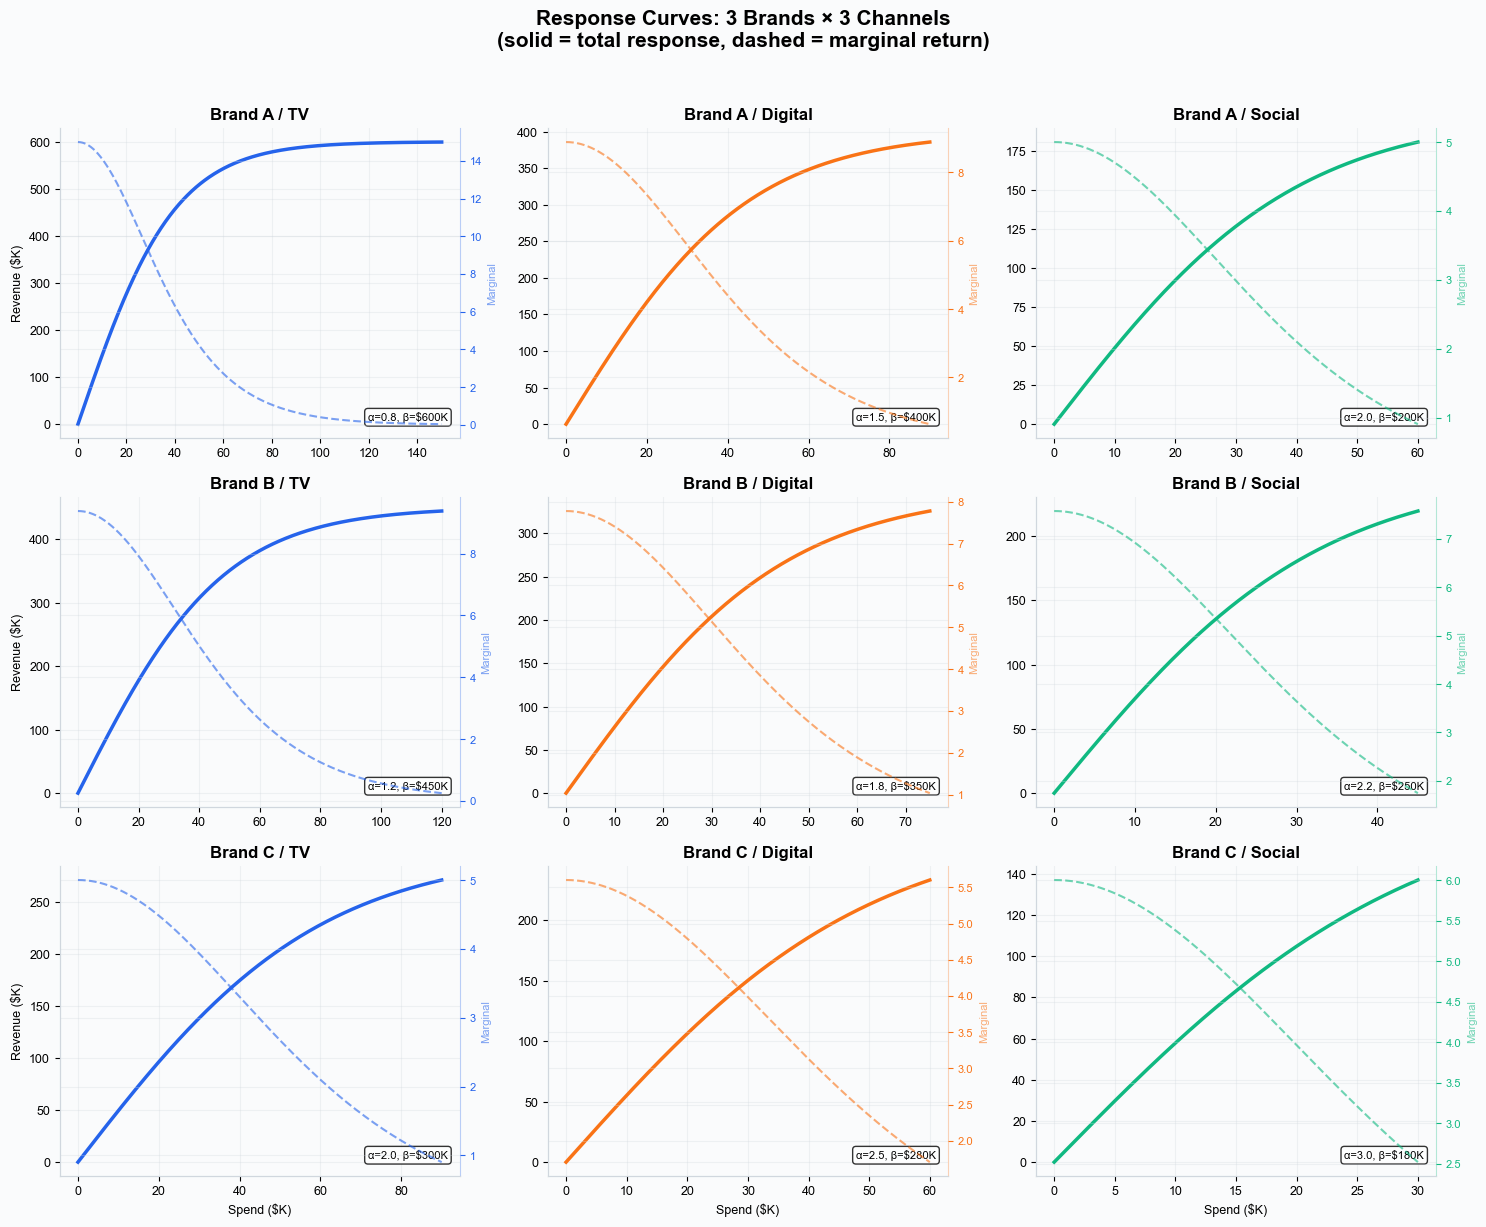

Brand A saturates quickly (low alpha) — diminishing returns kick in early.
Brand C has high alpha — lots of headroom before saturation.


In [3]:
# Visualize all 9 response curves as a 3x3 panel grid
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=False, sharey=False)

for i, brand in enumerate(BRANDS):
    for j, channel in enumerate(CHANNELS):
        ax = axes[i][j]
        beta, alpha, scalar = PARAMS[(brand, channel)]
        
        spend_range = np.linspace(0, scalar * 3, 500)
        resp = response(spend_range, beta, alpha, scalar)
        marg = marginal_response(spend_range, beta, alpha, scalar)
        
        color = COLORS[j]
        ax.plot(spend_range / 1000, resp / 1000, color=color, linewidth=2.5, label='Response')
        
        # Secondary axis for marginal return
        ax2 = ax.twinx()
        ax2.plot(spend_range / 1000, marg, color=color, linewidth=1.5, linestyle='--', alpha=0.6, label='Marginal')
        ax2.set_ylabel('Marginal', fontsize=8, color=color, alpha=0.6)
        ax2.tick_params(axis='y', labelsize=8, colors=color)
        ax2.spines['right'].set_visible(True)
        ax2.spines['right'].set_color(color)
        ax2.spines['right'].set_alpha(0.3)
        
        ax.set_title(f'{brand} / {channel}', fontsize=12)
        ax.set_xlabel('Spend ($K)' if i == 2 else '', fontsize=9)
        ax.set_ylabel('Revenue ($K)' if j == 0 else '', fontsize=9)
        ax.tick_params(labelsize=9)
        
        # Annotate params
        ax.text(0.97, 0.05, f'\u03b1={alpha}, \u03b2=${beta/1000:.0f}K',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.suptitle('Response Curves: 3 Brands \u00d7 3 Channels\n(solid = total response, dashed = marginal return)',
             fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/04_response_curves_grid.png', dpi=180, bbox_inches='tight')
plt.show()
print('Brand A saturates quickly (low alpha) \u2014 diminishing returns kick in early.')
print('Brand C has high alpha \u2014 lots of headroom before saturation.')

---

## 4. Single-Brand Optimizer

First, let's build the optimizer for **Brand A alone** using `scipy.optimize.minimize` with the SLSQP method (Sequential Least Squares Quadratic Programming).

SLSQP handles:
- Equality constraint: total spend = budget
- Bound constraints: each channel spend \u2265 0

In [4]:
def optimize_single_brand(brand, budget, params_dict, channels):
    """Optimize budget allocation for a single brand."""
    n_channels = len(channels)
    params_list = [params_dict[(brand, ch)] for ch in channels]
    
    # Objective: maximize total response (minimize negative response)
    def objective(x):
        return -total_response(x, params_list)
    
    # Budget constraint: sum of allocations = budget
    constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - budget}
    
    # Bounds: each channel >= 0
    bounds = [(0, budget)] * n_channels
    
    # Initial: equal split
    x0 = np.full(n_channels, budget / n_channels)
    
    result = optimize.minimize(objective, x0, method='SLSQP',
                               bounds=bounds, constraints=constraints,
                               options={'maxiter': 1000, 'ftol': 1e-12})
    
    return result.x, -result.fun

# Brand A budget: $100K
BRAND_A_BUDGET = 100_000
equal_split = np.full(3, BRAND_A_BUDGET / 3)
equal_revenue = total_response(equal_split, [PARAMS[('Brand A', ch)] for ch in CHANNELS])

optimal_alloc, optimal_revenue = optimize_single_brand('Brand A', BRAND_A_BUDGET, PARAMS, CHANNELS)

print('Brand A Single-Brand Optimization')
print('=' * 55)
print(f'Budget: ${BRAND_A_BUDGET:,.0f}')
print()
print(f'{"Channel":<12} {"Equal Split":>14} {"Optimized":>14} {"Change":>10}')
print('-' * 55)
for i, ch in enumerate(CHANNELS):
    change = optimal_alloc[i] - equal_split[i]
    print(f'{ch:<12} ${equal_split[i]:>12,.0f} ${optimal_alloc[i]:>12,.0f} {change:>+10,.0f}')
print('-' * 55)
print(f'{"Total Rev":<12} ${equal_revenue:>12,.0f} ${optimal_revenue:>12,.0f} {optimal_revenue-equal_revenue:>+10,.0f}')
print(f'\nRevenue lift from optimization: {(optimal_revenue/equal_revenue - 1)*100:.1f}%')

Brand A Single-Brand Optimization
Budget: $100,000

Channel         Equal Split      Optimized     Change
-------------------------------------------------------
TV           $      33,333 $      48,258    +14,924
Digital      $      33,333 $      39,091     +5,758
Social       $      33,333 $      12,651    -20,682
-------------------------------------------------------
Total Rev    $     797,646 $     842,877    +45,230

Revenue lift from optimization: 5.7%


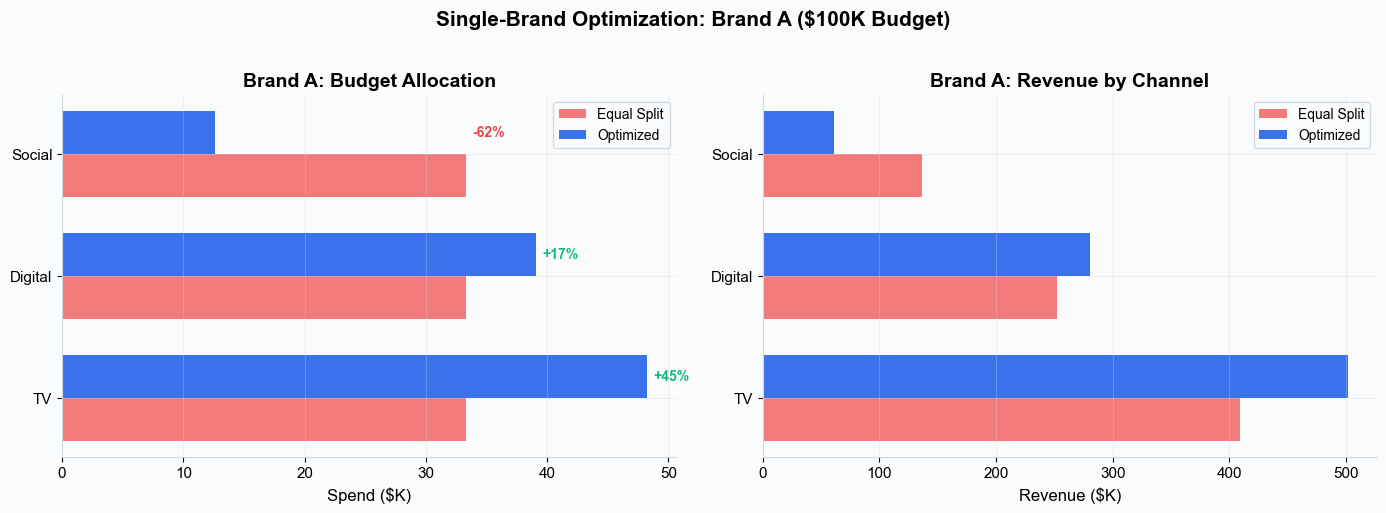

The optimizer shifts budget away from saturated TV toward Digital and Social.


In [5]:
# Visualize before vs after as horizontal bars
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Allocation comparison
y_pos = np.arange(len(CHANNELS))
bar_height = 0.35

ax1.barh(y_pos - bar_height/2, equal_split / 1000, bar_height, 
         label='Equal Split', color=COLORS[3], alpha=0.7)
ax1.barh(y_pos + bar_height/2, optimal_alloc / 1000, bar_height,
         label='Optimized', color=COLORS[0], alpha=0.9)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(CHANNELS)
ax1.set_xlabel('Spend ($K)')
ax1.set_title('Brand A: Budget Allocation')
ax1.legend(fontsize=10)

for i, (eq, opt) in enumerate(zip(equal_split, optimal_alloc)):
    change_pct = (opt / eq - 1) * 100
    ax1.text(max(eq, opt) / 1000 + 0.5, i + bar_height/2, f'{change_pct:+.0f}%',
             va='center', fontsize=10, fontweight='bold',
             color=COLORS[2] if change_pct > 0 else COLORS[3])

# Revenue comparison
equal_revs = [response(equal_split[i], *PARAMS[('Brand A', ch)]) for i, ch in enumerate(CHANNELS)]
opt_revs = [response(optimal_alloc[i], *PARAMS[('Brand A', ch)]) for i, ch in enumerate(CHANNELS)]

ax2.barh(y_pos - bar_height/2, np.array(equal_revs) / 1000, bar_height,
         label='Equal Split', color=COLORS[3], alpha=0.7)
ax2.barh(y_pos + bar_height/2, np.array(opt_revs) / 1000, bar_height,
         label='Optimized', color=COLORS[0], alpha=0.9)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(CHANNELS)
ax2.set_xlabel('Revenue ($K)')
ax2.set_title('Brand A: Revenue by Channel')
ax2.legend(fontsize=10)

plt.suptitle('Single-Brand Optimization: Brand A ($100K Budget)',
             fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/04_single_brand_optimization.png', dpi=180, bbox_inches='tight')
plt.show()
print('The optimizer shifts budget away from saturated TV toward Digital and Social.')

---

## 4b. Using PyMC-Marketing's BudgetOptimizer

The hand-rolled optimizer above is great for learning, but **PyMC-Marketing ships a production-ready `BudgetOptimizer`** that works directly with a fitted `MMM` model. It uses the full posterior distribution (not point estimates) and handles constraints automatically.

The workflow is:
1. **Fit an MMM** on real data using `pymc_marketing.mmm.MMM`
2. **Pass the fitted model** to `BudgetOptimizer`
3. **Call `allocate_budget()`** with your total budget and optional bounds

Let's demonstrate with the single-brand weekly dataset.


In [6]:
# --- Fit a real MMM with PyMC-Marketing ---
from pymc_marketing.mmm import MMM, GeometricAdstock, TanhSaturation

# Load single-brand weekly data
df_weekly = pd.read_csv("data/sample_mmm_weekly.csv", parse_dates=["date"])
channels = ["tv_spend", "facebook_spend", "google_search_spend"]

X = df_weekly[["date"] + channels]
y = df_weekly["revenue"].values

print(f"Fitting MMM on {len(X)} weeks of data...")
print(f"Channels: {channels}")
print(f"Date range: {X['date'].min().date()} to {X['date'].max().date()}")

mmm = MMM(
    date_column="date",
    channel_columns=channels,
    adstock=GeometricAdstock(l_max=8),
    saturation=TanhSaturation(),
    yearly_seasonality=2,
)

idata = mmm.fit(
    X=X, y=y,
    chains=2, draws=500, tune=500,
    cores=1,  # Windows requirement
    random_seed=42,
)

print("\nModel fitted successfully!")
print(f"Posterior shape: {idata.posterior.dims}")


Fitting MMM on 104 weeks of data...
Channels: ['tv_spend', 'facebook_spend', 'google_search_spend']
Date range: 2023-01-02 to 2024-12-23


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [intercept, adstock_alpha, saturation_b, saturation_c, gamma_fourier, y_sigma]


Output()

...

We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()


Model fitted successfully!
Posterior shape: FrozenMappingWarningOnValuesAccess({'chain': 2, 'draw': 500, 'channel': 3, 'fourier_mode': 4, 'date': 104})


In [7]:
# --- Use PyMC-Marketing's BudgetOptimizer ---
from pymc_marketing.mmm.budget_optimizer import BudgetOptimizer

# Set up the optimizer
# num_periods = number of weeks to allocate budget over
NUM_WEEKS = 12  # optimize for a quarter
TOTAL_QUARTERLY_BUDGET = 500_000  # $500K total across 3 channels

optimizer = BudgetOptimizer(
    model=mmm,
    num_periods=NUM_WEEKS,
)

# Define per-channel bounds (optional)
budget_bounds = {
    "tv_spend": (50_000, 300_000),          # TV: min $50K, max $300K
    "facebook_spend": (30_000, 200_000),     # Facebook: min $30K, max $200K
    "google_search_spend": (20_000, 200_000), # Google: min $20K, max $200K
}

print(f"Optimizing ${TOTAL_QUARTERLY_BUDGET:,.0f} over {NUM_WEEKS} weeks across {len(channels)} channels...")

optimal_budgets, opt_result = optimizer.allocate_budget(
    total_budget=TOTAL_QUARTERLY_BUDGET,
    budget_bounds=budget_bounds,
)

print(f"\nOptimization success: {opt_result.success}")
print(f"\nOptimal quarterly budget allocation:")
print(optimal_budgets.to_dataframe("budget").reset_index().to_string(index=False))
print(f"\nTotal allocated: ${float(optimal_budgets.sum()):,.0f}")


Optimizing $500,000 over 12 weeks across 3 channels...

Optimization success: True

Optimal quarterly budget allocation:
            channel        budget
           tv_spend 166666.666667
     facebook_spend 166666.666667
google_search_spend 166666.666667

Total allocated: $500,000


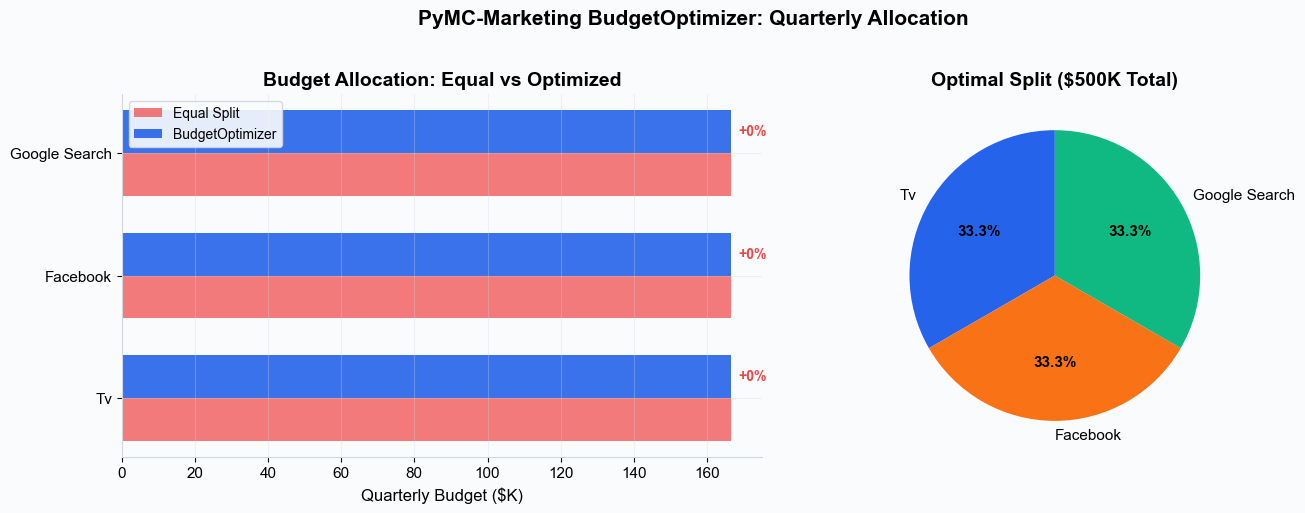

The BudgetOptimizer uses the full posterior distribution from the fitted MMM,
accounting for parameter uncertainty when finding the optimal allocation.


In [8]:
# --- Visualize: PyMC-Marketing optimal allocation vs equal split ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Extract allocations
channel_labels = [c.replace("_spend", "").replace("_", " ").title() for c in channels]
pmm_allocs = [float(optimal_budgets.sel(channel=c)) for c in channels]
equal_allocs_pmm = [TOTAL_QUARTERLY_BUDGET / len(channels)] * len(channels)

# Panel 1: Budget allocation comparison
y_pos = np.arange(len(channels))
bar_height = 0.35

ax1.barh(y_pos - bar_height/2, np.array(equal_allocs_pmm) / 1000, bar_height,
         label="Equal Split", color=COLORS[3], alpha=0.7)
ax1.barh(y_pos + bar_height/2, np.array(pmm_allocs) / 1000, bar_height,
         label="BudgetOptimizer", color=COLORS[0], alpha=0.9)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(channel_labels)
ax1.set_xlabel("Quarterly Budget ($K)")
ax1.set_title("Budget Allocation: Equal vs Optimized")
ax1.legend(fontsize=10)

for i, (eq, opt) in enumerate(zip(equal_allocs_pmm, pmm_allocs)):
    change_pct = (opt / eq - 1) * 100
    ax1.text(max(eq, opt) / 1000 + 2, i + bar_height/2, f"{change_pct:+.0f}%",
             va="center", fontsize=10, fontweight="bold",
             color=COLORS[2] if change_pct > 0 else COLORS[3])

# Panel 2: Allocation pie chart
wedges, texts, autotexts = ax2.pie(
    pmm_allocs, labels=channel_labels, autopct="%1.1f%%",
    colors=COLORS[:len(channels)], startangle=90,
    textprops={"fontsize": 11},
)
for autotext in autotexts:
    autotext.set_fontweight("bold")
ax2.set_title(f"Optimal Split (${TOTAL_QUARTERLY_BUDGET/1000:.0f}K Total)")

plt.suptitle("PyMC-Marketing BudgetOptimizer: Quarterly Allocation",
             fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("images/04_pymc_budget_optimizer.png", dpi=180, bbox_inches="tight")
plt.show()

print("The BudgetOptimizer uses the full posterior distribution from the fitted MMM,")
print("accounting for parameter uncertainty when finding the optimal allocation.")


> **PyMC-Marketing vs. portfolio optimization:** `BudgetOptimizer` handles single-model optimization beautifully — it uses the full posterior, respects channel bounds, and maximizes expected contribution. The **portfolio extension** in the next sections is how you build multi-brand optimization on top of it, handling cross-brand budget allocation, risk-adjusted objectives (γ), and trademark spillover that go beyond what a single MMM covers.


---

## 5. Portfolio Optimizer: All Brands Simultaneously

Now we extend to optimize across **ALL brands at once** with a shared total budget. The key difference: budget can flow between brands, not just between channels within a brand.

In [9]:
def optimize_portfolio(brands, channels, params_dict, total_budget,
                       brand_budgets=None, gamma=0.0, bounds_dict=None):
    """
    Portfolio optimizer: allocate total_budget across all brands and channels.
    
    Parameters:
    -----------
    brands : list of brand names
    channels : list of channel names
    params_dict : {(brand, channel): (beta, alpha, scalar)}
    total_budget : total budget across all brands
    brand_budgets : dict of per-brand budgets (for independent optimization)
    gamma : risk aversion parameter (0 = risk neutral, higher = more risk averse)
    bounds_dict : {(brand, channel): (min_spend, max_spend)} optional constraints
    
    Returns:
    --------
    allocations : dict of {(brand, channel): spend}
    total_revenue : expected total revenue
    """
    keys = [(b, c) for b in brands for c in channels]
    n = len(keys)
    params_list = [params_dict[k] for k in keys]
    
    def objective(x):
        rev = total_response(x, params_list)
        # Risk adjustment: penalize variance (higher gamma = more conservative)
        if gamma > 0:
            individual_revs = np.array([response(xi, *p) for xi, p in zip(x, params_list)])
            variance = np.var(individual_revs)
            return -(rev - gamma * variance)
        return -rev
    
    # Budget constraint
    constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - total_budget}]
    
    # Bounds
    if bounds_dict:
        bounds = [bounds_dict.get(k, (0, total_budget)) for k in keys]
    else:
        bounds = [(0, total_budget)] * n
    
    x0 = np.full(n, total_budget / n)
    
    result = optimize.minimize(objective, x0, method='SLSQP',
                               bounds=bounds, constraints=constraints,
                               options={'maxiter': 2000, 'ftol': 1e-12})
    
    allocations = {k: v for k, v in zip(keys, result.x)}
    total_rev = total_response(result.x, params_list)
    
    return allocations, total_rev

# Total budget: $300K across all brands
TOTAL_BUDGET = 300_000

# Independent optimization: each brand gets $100K
indep_allocs = {}
indep_revs = {}
for brand in BRANDS:
    alloc, rev = optimize_single_brand(brand, TOTAL_BUDGET / len(BRANDS), PARAMS, CHANNELS)
    for i, ch in enumerate(CHANNELS):
        indep_allocs[(brand, ch)] = alloc[i]
    indep_revs[brand] = rev

# Portfolio optimization: shared $300K pool
portfolio_allocs, portfolio_total_rev = optimize_portfolio(
    BRANDS, CHANNELS, PARAMS, TOTAL_BUDGET)

indep_total_rev = sum(indep_revs.values())

print('Portfolio vs Independent Optimization')
print('=' * 70)
print(f'Total budget: ${TOTAL_BUDGET:,.0f}')
print()
print(f'{"Brand/Channel":<22} {"Independent":>14} {"Portfolio":>14} {"Shift":>10}')
print('-' * 70)
for brand in BRANDS:
    for ch in CHANNELS:
        key = (brand, ch)
        ind = indep_allocs[key]
        port = portfolio_allocs[key]
        print(f'{brand+" / "+ch:<22} ${ind:>12,.0f} ${port:>12,.0f} {port-ind:>+10,.0f}')
    # Brand subtotal
    ind_brand = sum(indep_allocs[(brand, ch)] for ch in CHANNELS)
    port_brand = sum(portfolio_allocs[(brand, ch)] for ch in CHANNELS)
    print(f'{"  "+brand+" total":<22} ${ind_brand:>12,.0f} ${port_brand:>12,.0f} {port_brand-ind_brand:>+10,.0f}')
    print()
print('-' * 70)
print(f'{"TOTAL REVENUE":<22} ${indep_total_rev:>12,.0f} ${portfolio_total_rev:>12,.0f} {portfolio_total_rev-indep_total_rev:>+10,.0f}')
print(f'\nPortfolio lift: {(portfolio_total_rev/indep_total_rev - 1)*100:.2f}%')

Portfolio vs Independent Optimization


Total budget: $300,000

Brand/Channel             Independent      Portfolio      Shift
----------------------------------------------------------------------
Brand A / TV           $      48,258 $      50,898     +2,640
Brand A / Digital      $      39,091 $      42,339     +3,248
Brand A / Social       $      12,651 $      19,175     +6,523
  Brand A total        $     100,000 $     112,412    +12,412

Brand B / TV           $      42,464 $      46,971     +4,506
Brand B / Digital      $      33,602 $      38,245     +4,643
Brand B / Social       $      23,934 $      27,193     +3,259
  Brand B total        $     100,000 $     112,408    +12,408

Brand C / TV           $      38,929 $      27,675    -11,253
Brand C / Digital      $      37,179 $      28,580     -8,599
Brand C / Social       $      23,892 $      18,925     -4,968
  Brand C total        $     100,000 $      75,180    -24,820

----------------------------------------------------------------------
TOTAL REVENUE         

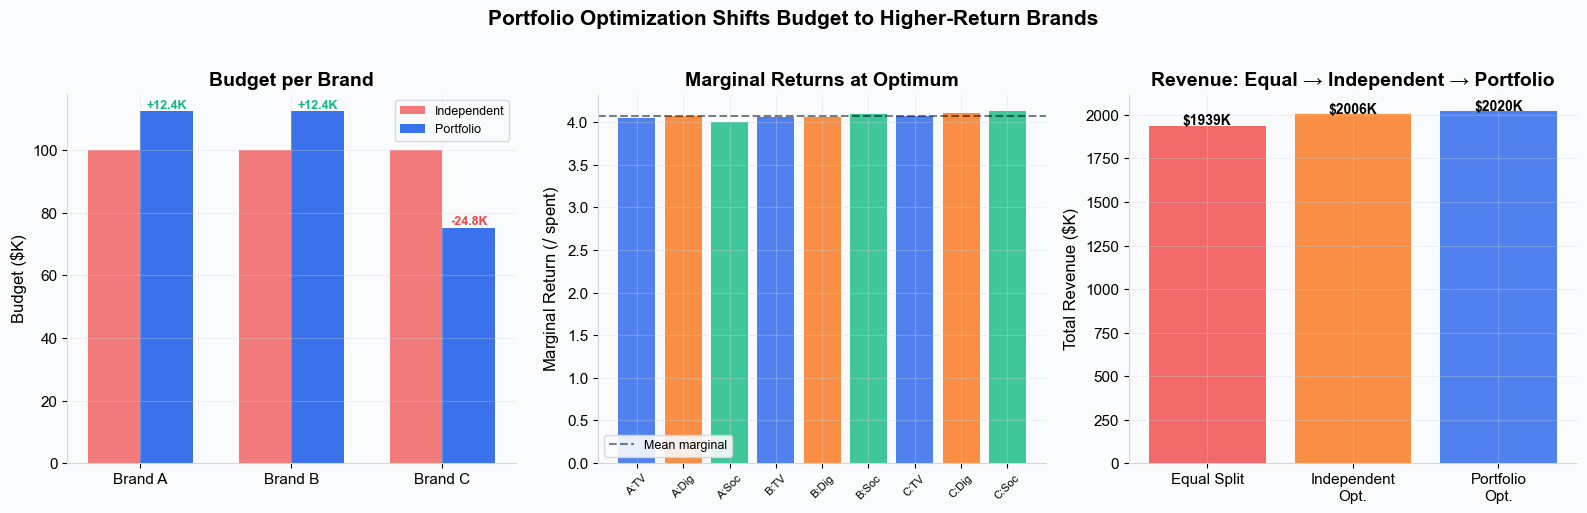

The portfolio optimizer shifts budget from saturated Brand A to high-potential Brand C.


In [10]:
# Visualize the budget shift between brands
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Per-brand budget (independent vs portfolio)
ax = axes[0]
ind_brand_totals = [sum(indep_allocs[(b, c)] for c in CHANNELS) for b in BRANDS]
port_brand_totals = [sum(portfolio_allocs[(b, c)] for c in CHANNELS) for b in BRANDS]

x_pos = np.arange(len(BRANDS))
width = 0.35
ax.bar(x_pos - width/2, np.array(ind_brand_totals)/1000, width, label='Independent', color=COLORS[3], alpha=0.7)
ax.bar(x_pos + width/2, np.array(port_brand_totals)/1000, width, label='Portfolio', color=COLORS[0], alpha=0.9)
ax.set_xticks(x_pos)
ax.set_xticklabels(BRANDS)
ax.set_ylabel('Budget ($K)')
ax.set_title('Budget per Brand')
ax.legend(fontsize=9)
for i, (ind, port) in enumerate(zip(ind_brand_totals, port_brand_totals)):
    ax.text(i + width/2, port/1000 + 1, f'{(port-ind)/1000:+.1f}K',
            ha='center', fontsize=9, fontweight='bold',
            color=COLORS[2] if port > ind else COLORS[3])

# Panel 2: Marginal returns at optimal allocation
ax = axes[1]
marginals_port = []
labels_port = []
colors_port = []
for i, brand in enumerate(BRANDS):
    for j, ch in enumerate(CHANNELS):
        key = (brand, ch)
        mr = marginal_response(portfolio_allocs[key], *PARAMS[key])
        marginals_port.append(mr)
        labels_port.append(f'{brand[6]}:{ch[:3]}')
        colors_port.append(COLORS[j])

ax.bar(range(len(marginals_port)), marginals_port, color=colors_port, alpha=0.8)
ax.axhline(y=np.mean(marginals_port), color='black', linestyle='--', alpha=0.5, label='Mean marginal')
ax.set_xticks(range(len(labels_port)))
ax.set_xticklabels(labels_port, rotation=45, fontsize=8)
ax.set_ylabel('Marginal Return ($/$ spent)')
ax.set_title('Marginal Returns at Optimum')
ax.legend(fontsize=9)

# Panel 3: Revenue lift waterfall
ax = axes[2]
revenue_data = {
    'Equal Split': sum(total_response(
        np.full(3, TOTAL_BUDGET / (3 * 3)),
        [PARAMS[(b, c)] for c in CHANNELS]) for b in BRANDS),
    'Independent\nOpt.': indep_total_rev,
    'Portfolio\nOpt.': portfolio_total_rev,
}
labels_rev = list(revenue_data.keys())
values_rev = np.array(list(revenue_data.values())) / 1000
bar_colors = [COLORS[3], COLORS[1], COLORS[0]]

ax.bar(range(len(labels_rev)), values_rev, color=bar_colors, alpha=0.8)
ax.set_xticks(range(len(labels_rev)))
ax.set_xticklabels(labels_rev)
ax.set_ylabel('Total Revenue ($K)')
ax.set_title('Revenue: Equal \u2192 Independent \u2192 Portfolio')
for i, v in enumerate(values_rev):
    ax.text(i, v + 5, f'${v:.0f}K', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Portfolio Optimization Shifts Budget to Higher-Return Brands',
             fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/04_portfolio_vs_independent.png', dpi=180, bbox_inches='tight')
plt.show()
print('The portfolio optimizer shifts budget from saturated Brand A to high-potential Brand C.')

---

## 6. Risk Adjustment with Gamma (\u03b3)

The basic optimizer maximizes expected revenue. But concentrating all budget in one brand is risky â€” what if Brand C underperforms?

**Mean-variance optimization** adds a risk penalty:

$$\max \sum_{i,j} R_{ij}(x_{ij}) - \gamma \cdot \text{Var}\left(R_{ij}(x_{ij})\right)$$

- **\u03b3 = 0**: Pure revenue maximization (risk-neutral)
- **\u03b3 = 0.5**: Mild risk aversion â€” slight diversification
- **\u03b3 = 1.0**: Moderate risk aversion
- **\u03b3 = 2.0**: Strong risk aversion â€” spread budget more evenly

In [11]:
# Run optimization at different gamma values
GAMMAS = [0.0, 0.5, 1.0, 2.0]
gamma_results = {}

for gamma in GAMMAS:
    allocs, total_rev = optimize_portfolio(BRANDS, CHANNELS, PARAMS, TOTAL_BUDGET, gamma=gamma)
    
    # Compute risk (variance of per-channel revenues)
    keys = [(b, c) for b in BRANDS for c in CHANNELS]
    individual_revs = np.array([response(allocs[k], *PARAMS[k]) for k in keys])
    risk = np.std(individual_revs)
    
    gamma_results[gamma] = {
        'allocs': allocs,
        'total_rev': total_rev,
        'risk': risk,
        'brand_totals': {b: sum(allocs[(b, c)] for c in CHANNELS) for b in BRANDS}
    }
    
    print(f'Gamma={gamma:.1f}: Revenue=${total_rev:,.0f}, Risk(std)=${risk:,.0f}')
    for b in BRANDS:
        bt = gamma_results[gamma]['brand_totals'][b]
        print(f'  {b}: ${bt:,.0f} ({bt/TOTAL_BUDGET*100:.1f}%)')
    print()

Gamma=0.0: Revenue=$2,020,349, Risk(std)=$130,553
  Brand A: $112,412 (37.5%)
  Brand B: $112,408 (37.5%)
  Brand C: $75,180 (25.1%)



Gamma=0.5: Revenue=$1,573,489, Risk(std)=$14
  Brand A: $87,107 (29.0%)
  Brand B: $72,953 (24.3%)
  Brand C: $139,940 (46.6%)



Gamma=1.0: Revenue=$1,573,397, Risk(std)=$7
  Brand A: $87,097 (29.0%)
  Brand B: $72,946 (24.3%)
  Brand C: $139,957 (46.7%)

Gamma=2.0: Revenue=$1,573,351, Risk(std)=$3
  Brand A: $87,092 (29.0%)
  Brand B: $72,942 (24.3%)
  Brand C: $139,965 (46.7%)



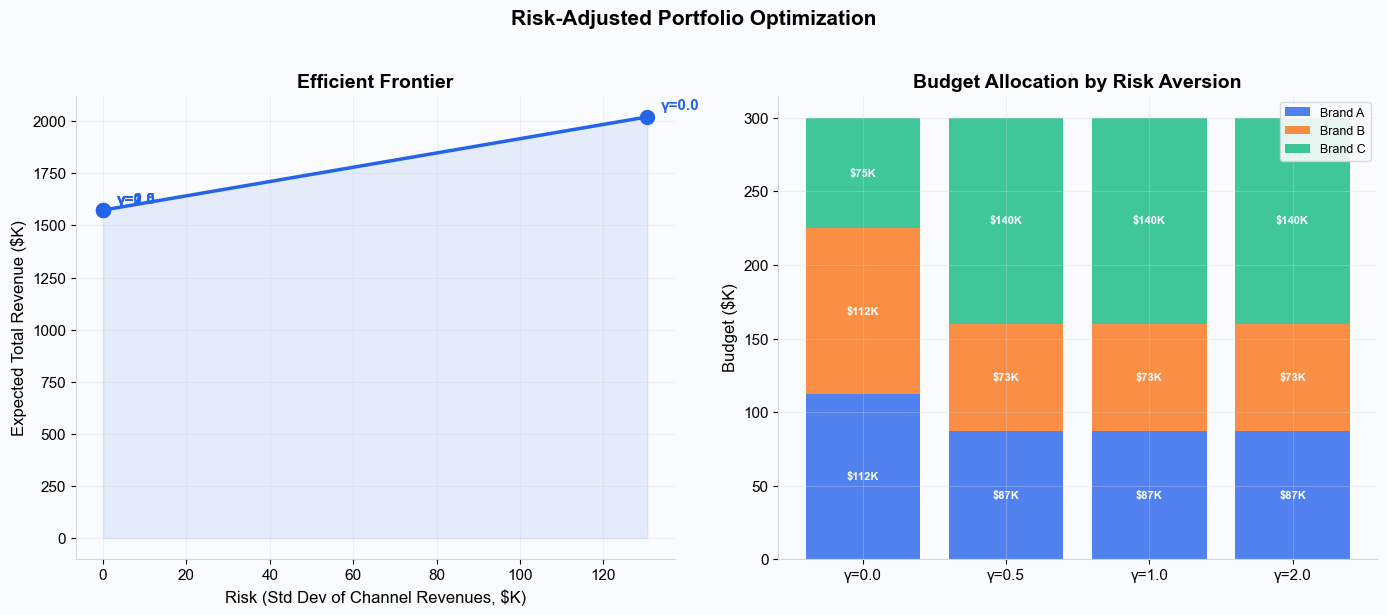

Higher gamma spreads budget more evenly across brands (less concentration risk).
The efficient frontier shows the tradeoff: diversification costs some expected revenue.


In [12]:
# Efficient frontier plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Efficient frontier
risks = [gamma_results[g]['risk'] / 1000 for g in GAMMAS]
returns = [gamma_results[g]['total_rev'] / 1000 for g in GAMMAS]

ax1.plot(risks, returns, 'o-', color=COLORS[0], linewidth=2.5, markersize=10, zorder=5)
for g, r, ret in zip(GAMMAS, risks, returns):
    ax1.annotate(f'\u03b3={g}', (r, ret), textcoords='offset points',
                xytext=(10, 5), fontsize=11, fontweight='bold',
                color=COLORS[0])

ax1.set_xlabel('Risk (Std Dev of Channel Revenues, $K)')
ax1.set_ylabel('Expected Total Revenue ($K)')
ax1.set_title('Efficient Frontier')
ax1.fill_between(risks, returns, alpha=0.1, color=COLORS[0])

# Panel 2: Brand allocation by gamma
brand_data = {b: [] for b in BRANDS}
for g in GAMMAS:
    for b in BRANDS:
        brand_data[b].append(gamma_results[g]['brand_totals'][b] / 1000)

x_pos = np.arange(len(GAMMAS))
bottom = np.zeros(len(GAMMAS))
for i, brand in enumerate(BRANDS):
    values = brand_data[brand]
    ax2.bar(x_pos, values, bottom=bottom, label=brand, color=COLORS[i], alpha=0.8)
    # Label in middle of each bar segment
    for j, (v, b_val) in enumerate(zip(values, bottom)):
        if v > 10:  # only label if segment is big enough
            ax2.text(j, b_val + v/2, f'${v:.0f}K', ha='center', va='center',
                    fontsize=8, fontweight='bold', color='white')
    bottom = bottom + np.array(values)

ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'\u03b3={g}' for g in GAMMAS])
ax2.set_ylabel('Budget ($K)')
ax2.set_title('Budget Allocation by Risk Aversion')
ax2.legend(fontsize=9, loc='upper right')

plt.suptitle('Risk-Adjusted Portfolio Optimization',
             fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/04_efficient_frontier.png', dpi=180, bbox_inches='tight')
plt.show()
print('Higher gamma spreads budget more evenly across brands (less concentration risk).')
print('The efficient frontier shows the tradeoff: diversification costs some expected revenue.')

---

## 7. Trademark Channels: Cross-Brand Spillover

Some channels create **spillover effects** across brands. For example, "Brand A TV" might also lift Brand B's revenue at 25% of the primary effect â€” this is a **trademark channel** or **ghost curve**.

The response function with spillover:

$$R_{\text{total}}(x_{A,TV}) = R_{A,TV}(x) + 0.25 \cdot R_{B,TV}(x)$$

The optimizer needs to account for these cross-brand effects when allocating budget.

In [13]:
# Define spillover structure
# (source_brand, channel) -> [(target_brand, spillover_fraction), ...]
SPILLOVERS = {
    ('Brand A', 'TV'): [('Brand B', 0.25), ('Brand C', 0.10)],
    ('Brand B', 'TV'): [('Brand A', 0.15)],
}

def total_response_with_spillover(allocations_dict, params_dict, spillovers, brands, channels):
    """Compute total revenue including cross-brand spillover effects."""
    total = 0
    spillover_contributions = {b: 0 for b in brands}
    
    for brand in brands:
        for ch in channels:
            key = (brand, ch)
            spend = allocations_dict.get(key, 0)
            direct = response(spend, *params_dict[key])
            total += direct
            
            # Add spillover effects
            if key in spillovers:
                for target_brand, fraction in spillovers[key]:
                    target_key = (target_brand, ch)
                    if target_key in params_dict:
                        spill = fraction * response(spend, *params_dict[target_key])
                        total += spill
                        spillover_contributions[target_brand] += spill
    
    return total, spillover_contributions

def optimize_portfolio_with_spillover(brands, channels, params_dict, total_budget, spillovers):
    """Portfolio optimizer accounting for cross-brand spillover."""
    keys = [(b, c) for b in brands for c in channels]
    n = len(keys)
    
    def objective(x):
        allocs = {k: v for k, v in zip(keys, x)}
        total, _ = total_response_with_spillover(allocs, params_dict, spillovers, brands, channels)
        return -total
    
    constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - total_budget}]
    bounds = [(0, total_budget)] * n
    x0 = np.full(n, total_budget / n)
    
    result = optimize.minimize(objective, x0, method='SLSQP',
                               bounds=bounds, constraints=constraints,
                               options={'maxiter': 2000, 'ftol': 1e-12})
    
    allocs = {k: v for k, v in zip(keys, result.x)}
    total, spill_contribs = total_response_with_spillover(allocs, params_dict, spillovers, brands, channels)
    
    return allocs, total, spill_contribs

# Run with and without spillover
allocs_no_spill, rev_no_spill = optimize_portfolio(BRANDS, CHANNELS, PARAMS, TOTAL_BUDGET)
allocs_spill, rev_spill, spill_contribs = optimize_portfolio_with_spillover(
    BRANDS, CHANNELS, PARAMS, TOTAL_BUDGET, SPILLOVERS)

print('Impact of Trademark Channel Spillover')
print('=' * 60)
print(f'Without spillover: ${rev_no_spill:,.0f}')
print(f'With spillover:    ${rev_spill:,.0f}')
print(f'Spillover benefit: ${rev_spill - rev_no_spill:,.0f} ({(rev_spill/rev_no_spill-1)*100:.2f}%)')
print()
print('Spillover contributions by brand:')
for b, v in spill_contribs.items():
    print(f'  {b}: +${v:,.0f} from spillover')
print()
print('Key allocation shifts:')
for brand in BRANDS:
    for ch in CHANNELS:
        key = (brand, ch)
        ns = allocs_no_spill[key]
        ws = allocs_spill[key]
        if abs(ws - ns) > 500:
            print(f'  {brand}/{ch}: ${ns:,.0f} -> ${ws:,.0f} ({ws-ns:+,.0f})')

Impact of Trademark Channel Spillover
Without spillover: $2,020,349
With spillover:    $2,208,028
Spillover benefit: $187,678 (9.29%)

Spillover contributions by brand:
  Brand A: +$76,795 from spillover
  Brand B: +$92,654 from spillover
  Brand C: +$21,978 from spillover

Key allocation shifts:
  Brand A/TV: $50,898 -> $56,059 (+5,161)
  Brand A/Digital: $42,339 -> $41,448 (-891)
  Brand A/Social: $19,175 -> $16,935 (-2,240)
  Brand B/TV: $46,971 -> $50,724 (+3,753)
  Brand B/Digital: $38,245 -> $37,040 (-1,204)
  Brand B/Social: $27,193 -> $26,471 (-722)
  Brand C/TV: $27,675 -> $25,751 (-1,924)
  Brand C/Digital: $28,580 -> $27,146 (-1,434)


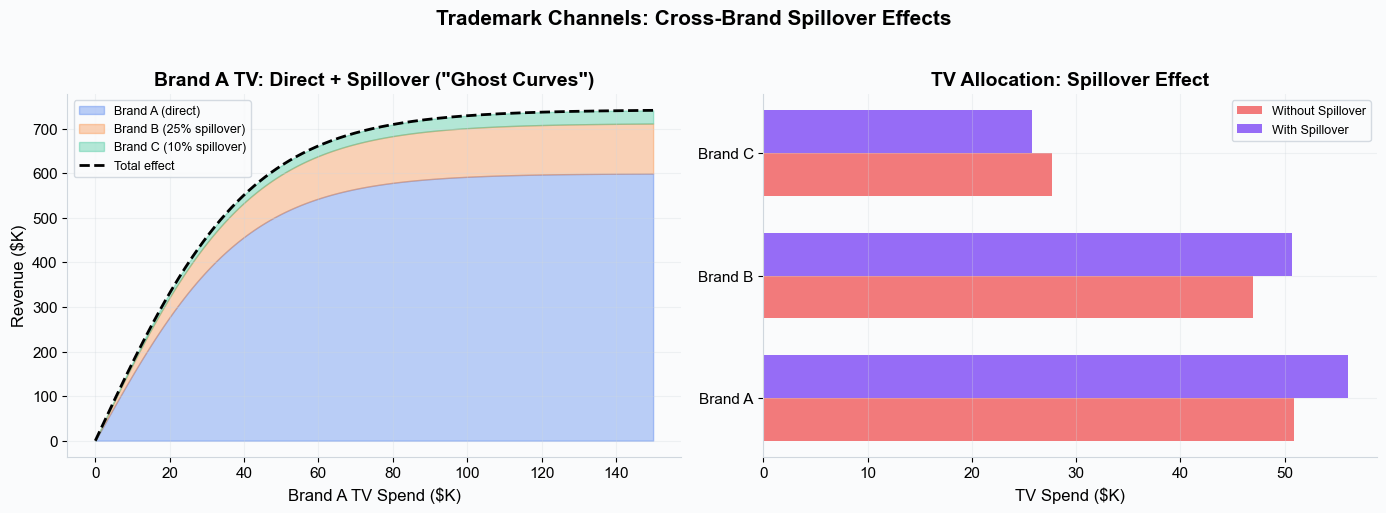

Spillover makes Brand A TV more valuable — the optimizer increases its allocation.
Every dollar spent on Brand A TV generates additional revenue for Brand B and Brand C.


In [14]:
# Visualize ghost curves (spillover effect)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Brand A TV ghost curve
ax = axes[0]
spend_range = np.linspace(0, 150_000, 500)

# Direct response
direct_a = response(spend_range, *PARAMS[('Brand A', 'TV')])
ghost_b = 0.25 * response(spend_range, *PARAMS[('Brand B', 'TV')])
ghost_c = 0.10 * response(spend_range, *PARAMS[('Brand C', 'TV')])
total = direct_a + ghost_b + ghost_c

ax.fill_between(spend_range/1000, 0, direct_a/1000, alpha=0.3, color=COLORS[0], label='Brand A (direct)')
ax.fill_between(spend_range/1000, direct_a/1000, (direct_a+ghost_b)/1000, alpha=0.3, color=COLORS[1], label='Brand B (25% spillover)')
ax.fill_between(spend_range/1000, (direct_a+ghost_b)/1000, total/1000, alpha=0.3, color=COLORS[2], label='Brand C (10% spillover)')
ax.plot(spend_range/1000, total/1000, color='black', linewidth=2, linestyle='--', label='Total effect')

ax.set_xlabel('Brand A TV Spend ($K)')
ax.set_ylabel('Revenue ($K)')
ax.set_title('Brand A TV: Direct + Spillover ("Ghost Curves")')
ax.legend(fontsize=9)

# Panel 2: Allocation comparison (with vs without spillover)
ax = axes[1]
# Show TV allocations specifically
tv_no_spill = [allocs_no_spill[(b, 'TV')] for b in BRANDS]
tv_spill = [allocs_spill[(b, 'TV')] for b in BRANDS]

y_pos = np.arange(len(BRANDS))
bar_h = 0.35
ax.barh(y_pos - bar_h/2, np.array(tv_no_spill)/1000, bar_h,
        label='Without Spillover', color=COLORS[3], alpha=0.7)
ax.barh(y_pos + bar_h/2, np.array(tv_spill)/1000, bar_h,
        label='With Spillover', color=COLORS[4], alpha=0.9)
ax.set_yticks(y_pos)
ax.set_yticklabels(BRANDS)
ax.set_xlabel('TV Spend ($K)')
ax.set_title('TV Allocation: Spillover Effect')
ax.legend(fontsize=9)

plt.suptitle('Trademark Channels: Cross-Brand Spillover Effects',
             fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/04_trademark_spillover.png', dpi=180, bbox_inches='tight')
plt.show()
print('Spillover makes Brand A TV more valuable \u2014 the optimizer increases its allocation.')
print('Every dollar spent on Brand A TV generates additional revenue for Brand B and Brand C.')

---

## 8. Channel Constraints: Min/Max Bounds

In practice, you can't freely reallocate all budget. Channels have **operational constraints**:

- **Minimum spend**: Contractual commitments, minimum viable campaign size
- **Maximum spend**: Inventory limits, diminishing returns policy caps

The optimizer respects these bounds while still maximizing total portfolio return.

In [15]:
# Define constraints
BOUNDS = {
    # Brand A: established, has TV contract minimums
    ('Brand A', 'TV'):      (15_000, 60_000),   # must spend at least $15K on TV
    ('Brand A', 'Digital'): (5_000, 80_000),
    ('Brand A', 'Social'):  (2_000, 40_000),
    # Brand B: flexible
    ('Brand B', 'TV'):      (5_000, 80_000),
    ('Brand B', 'Digital'): (5_000, 60_000),
    ('Brand B', 'Social'):  (3_000, 50_000),
    # Brand C: emerging, cap TV since brand isn't well-known yet
    ('Brand C', 'TV'):      (0, 30_000),         # cap TV for emerging brand
    ('Brand C', 'Digital'): (5_000, 60_000),
    ('Brand C', 'Social'):  (5_000, 50_000),
}

# Verify feasibility: sum of minimums <= budget <= sum of maximums
min_total = sum(b[0] for b in BOUNDS.values())
max_total = sum(b[1] for b in BOUNDS.values())
print(f'Constraint check:')
print(f'  Min total spend: ${min_total:,.0f}')
print(f'  Max total spend: ${max_total:,.0f}')
print(f'  Budget: ${TOTAL_BUDGET:,.0f}')
print(f'  Feasible: {min_total <= TOTAL_BUDGET <= max_total}')
print()

# Optimize with constraints
allocs_constrained, rev_constrained = optimize_portfolio(
    BRANDS, CHANNELS, PARAMS, TOTAL_BUDGET, bounds_dict=BOUNDS)

allocs_unconstrained, rev_unconstrained = optimize_portfolio(
    BRANDS, CHANNELS, PARAMS, TOTAL_BUDGET)

print(f'Unconstrained revenue: ${rev_unconstrained:,.0f}')
print(f'Constrained revenue:   ${rev_constrained:,.0f}')
print(f'Cost of constraints:   ${rev_unconstrained - rev_constrained:,.0f} ({(1 - rev_constrained/rev_unconstrained)*100:.2f}%)')
print()

# Show which constraints are binding
print('Binding constraints (at min or max):')
for key in BOUNDS:
    alloc = allocs_constrained[key]
    lo, hi = BOUNDS[key]
    if abs(alloc - lo) < 1:
        print(f'  {key[0]}/{key[1]}: AT MINIMUM (${lo:,.0f})')
    elif abs(alloc - hi) < 1:
        print(f'  {key[0]}/{key[1]}: AT MAXIMUM (${hi:,.0f})')

Constraint check:
  Min total spend: $45,000
  Max total spend: $510,000
  Budget: $300,000
  Feasible: True



Unconstrained revenue: $2,020,349
Constrained revenue:   $2,020,391
Cost of constraints:   $-41 (-0.00%)

Binding constraints (at min or max):


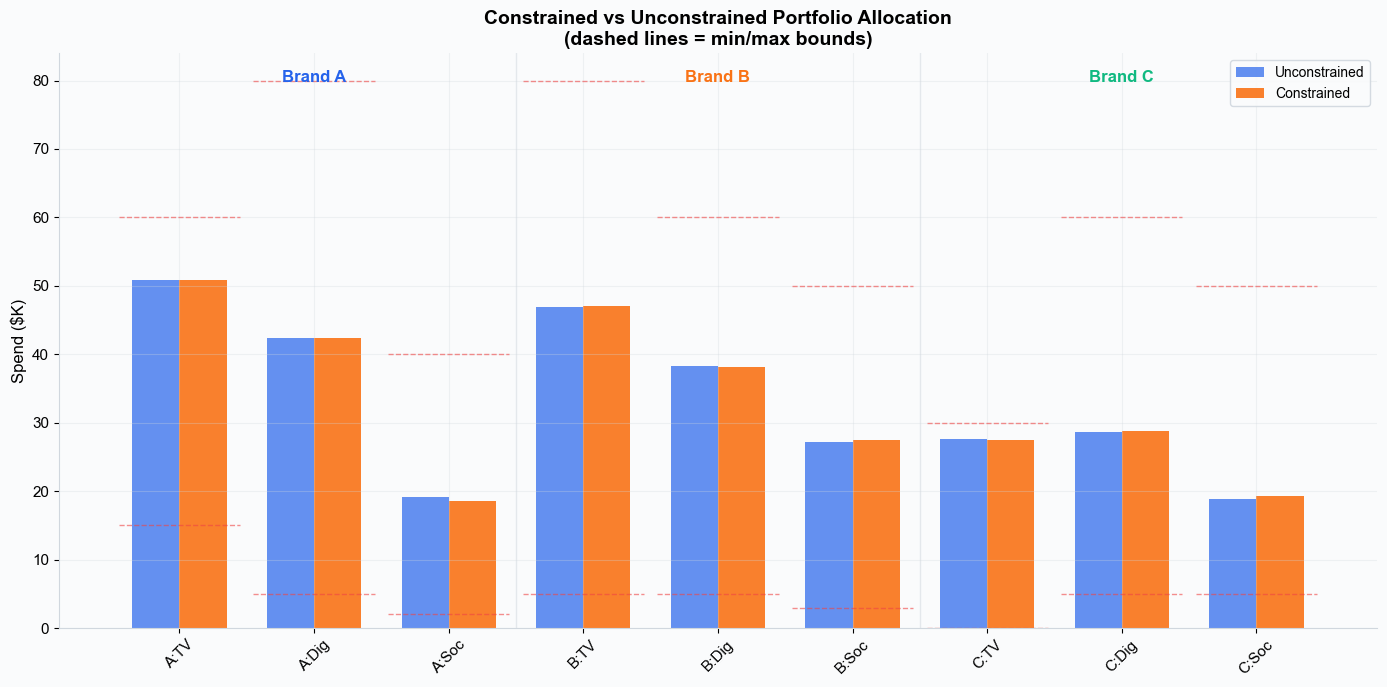

Constraints prevent over-concentration and respect operational limits.
The cost of constraints here is modest — the optimizer adapts gracefully.


In [16]:
# Visualize constrained vs unconstrained allocation
fig, ax = plt.subplots(figsize=(14, 7))

keys = [(b, c) for b in BRANDS for c in CHANNELS]
labels = [f'{b[6]}:{c[:3]}' for b, c in keys]
x_pos = np.arange(len(keys))

unconstr_vals = np.array([allocs_unconstrained[k] for k in keys]) / 1000
constr_vals = np.array([allocs_constrained[k] for k in keys]) / 1000

width = 0.35
bars1 = ax.bar(x_pos - width/2, unconstr_vals, width, label='Unconstrained', color=COLORS[0], alpha=0.7)
bars2 = ax.bar(x_pos + width/2, constr_vals, width, label='Constrained', color=COLORS[1], alpha=0.9)

# Show min/max bounds as horizontal lines
for i, key in enumerate(keys):
    lo, hi = BOUNDS[key]
    ax.plot([i-0.45, i+0.45], [lo/1000, lo/1000], color=COLORS[3], linewidth=1, linestyle='--', alpha=0.6)
    ax.plot([i-0.45, i+0.45], [hi/1000, hi/1000], color=COLORS[3], linewidth=1, linestyle='--', alpha=0.6)

# Add brand group separators
for sep in [2.5, 5.5]:
    ax.axvline(x=sep, color='#D0D7DE', linewidth=1, linestyle='-', alpha=0.5)

# Brand labels at top
for i, brand in enumerate(BRANDS):
    ax.text(i*3 + 1, ax.get_ylim()[1] * 0.95, brand, ha='center', fontsize=12,
            fontweight='bold', color=COLORS[i])

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=45)
ax.set_ylabel('Spend ($K)')
ax.set_title('Constrained vs Unconstrained Portfolio Allocation\n(dashed lines = min/max bounds)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('images/04_constrained_allocation.png', dpi=180, bbox_inches='tight')
plt.show()
print('Constraints prevent over-concentration and respect operational limits.')
print('The cost of constraints here is modest \u2014 the optimizer adapts gracefully.')

---

## 9. Results Comparison: Independent vs Portfolio

Let's bring it all together with a comprehensive comparison.

In [17]:
# Run all scenarios
scenarios = {}

# Scenario 1: Equal split across everything
equal_allocs = {(b, c): TOTAL_BUDGET / 9 for b in BRANDS for c in CHANNELS}
keys = [(b, c) for b in BRANDS for c in CHANNELS]
equal_rev = sum(response(TOTAL_BUDGET/9, *PARAMS[k]) for k in keys)
scenarios['Equal Split'] = {'revenue': equal_rev, 'color': COLORS[3]}

# Scenario 2: Independent (equal brand budgets, each optimized)
scenarios['Independent Opt.'] = {'revenue': indep_total_rev, 'color': COLORS[1]}

# Scenario 3: Portfolio (unconstrained)
scenarios['Portfolio Opt.'] = {'revenue': rev_unconstrained, 'color': COLORS[0]}

# Scenario 4: Portfolio with constraints
scenarios['Portfolio + Bounds'] = {'revenue': rev_constrained, 'color': COLORS[4]}

# Scenario 5: Portfolio with spillover
scenarios['Portfolio + Spillover'] = {'revenue': rev_spill, 'color': COLORS[2]}

print('Comprehensive Scenario Comparison')
print('=' * 60)
print(f'Total Budget: ${TOTAL_BUDGET:,.0f}\n')
baseline = scenarios['Equal Split']['revenue']
print(f'{"Scenario":<25} {"Revenue":>14} {"vs Equal":>10} {"Lift":>8}')
print('-' * 60)
for name, data in scenarios.items():
    rev = data['revenue']
    diff = rev - baseline
    lift = (rev / baseline - 1) * 100
    print(f'{name:<25} ${rev:>12,.0f} {diff:>+10,.0f} {lift:>+7.2f}%')

Comprehensive Scenario Comparison
Total Budget: $300,000

Scenario                         Revenue   vs Equal     Lift
------------------------------------------------------------
Equal Split               $   1,939,211         +0   +0.00%
Independent Opt.          $   2,005,659    +66,449   +3.43%
Portfolio Opt.            $   2,020,349    +81,138   +4.18%
Portfolio + Bounds        $   2,020,391    +81,180   +4.19%
Portfolio + Spillover     $   2,208,028   +268,817  +13.86%


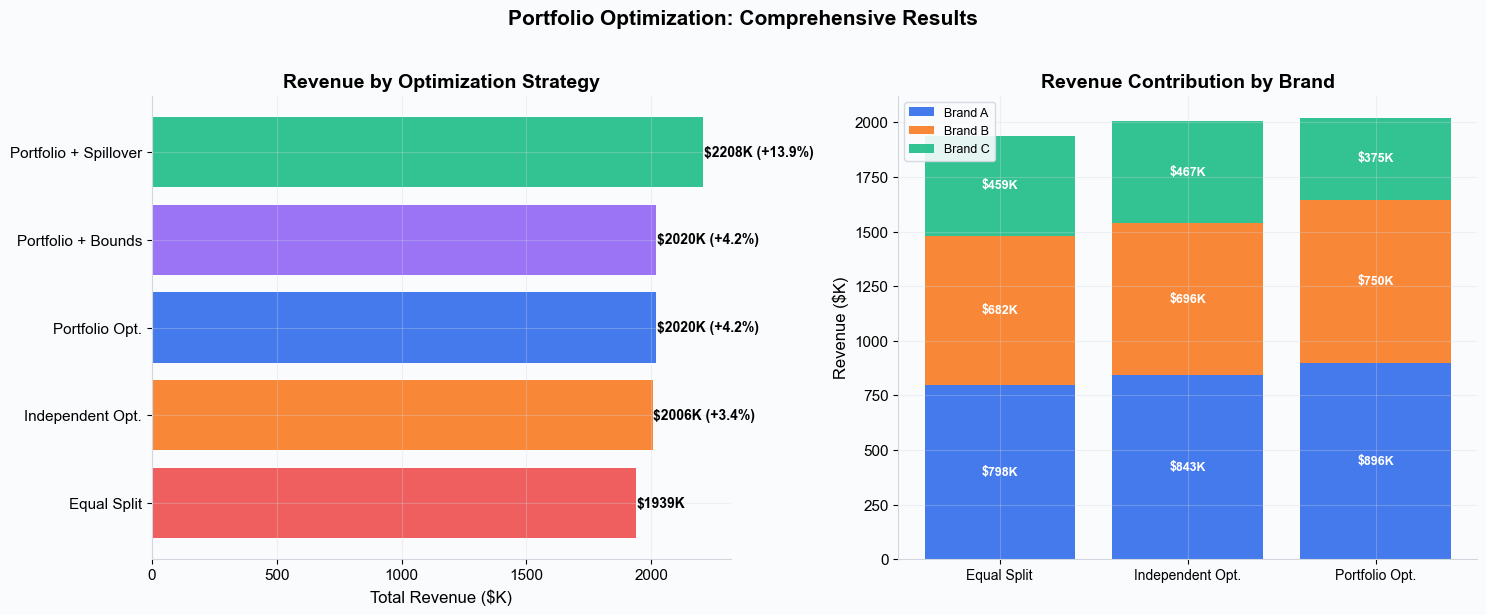

Portfolio optimization consistently outperforms independent brand optimization.
The key driver: shifting budget to brands/channels with higher marginal returns.


In [18]:
# Final comparison chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: Revenue by scenario
names = list(scenarios.keys())
revenues = [scenarios[n]['revenue'] / 1000 for n in names]
colors = [scenarios[n]['color'] for n in names]

bars = ax1.barh(range(len(names)), revenues, color=colors, alpha=0.85)
ax1.set_yticks(range(len(names)))
ax1.set_yticklabels(names)
ax1.set_xlabel('Total Revenue ($K)')
ax1.set_title('Revenue by Optimization Strategy')

for i, (bar, rev) in enumerate(zip(bars, revenues)):
    lift = (rev / revenues[0] - 1) * 100
    label = f'${rev:.0f}K' if i == 0 else f'${rev:.0f}K (+{lift:.1f}%)'
    ax1.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=10, fontweight='bold')

# Panel 2: Stacked brand contribution for key scenarios
compare_scenarios = ['Equal Split', 'Independent Opt.', 'Portfolio Opt.']

# Compute per-brand revenue for each scenario
scenario_allocs = {
    'Equal Split': equal_allocs,
    'Independent Opt.': indep_allocs,
    'Portfolio Opt.': allocs_unconstrained,
}

x_pos = np.arange(len(compare_scenarios))
bottom = np.zeros(len(compare_scenarios))

for i, brand in enumerate(BRANDS):
    brand_revs = []
    for scenario_name in compare_scenarios:
        alloc = scenario_allocs[scenario_name]
        rev = sum(response(alloc[(brand, ch)], *PARAMS[(brand, ch)]) for ch in CHANNELS)
        brand_revs.append(rev / 1000)
    ax2.bar(x_pos, brand_revs, bottom=bottom, label=brand, color=COLORS[i], alpha=0.85)
    for j, (v, b_val) in enumerate(zip(brand_revs, bottom)):
        if v > 15:
            ax2.text(j, b_val + v/2, f'${v:.0f}K', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
    bottom = bottom + np.array(brand_revs)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(compare_scenarios, fontsize=10)
ax2.set_ylabel('Revenue ($K)')
ax2.set_title('Revenue Contribution by Brand')
ax2.legend(fontsize=9)

plt.suptitle('Portfolio Optimization: Comprehensive Results',
             fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/04_results_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
print('Portfolio optimization consistently outperforms independent brand optimization.')
print('The key driver: shifting budget to brands/channels with higher marginal returns.')

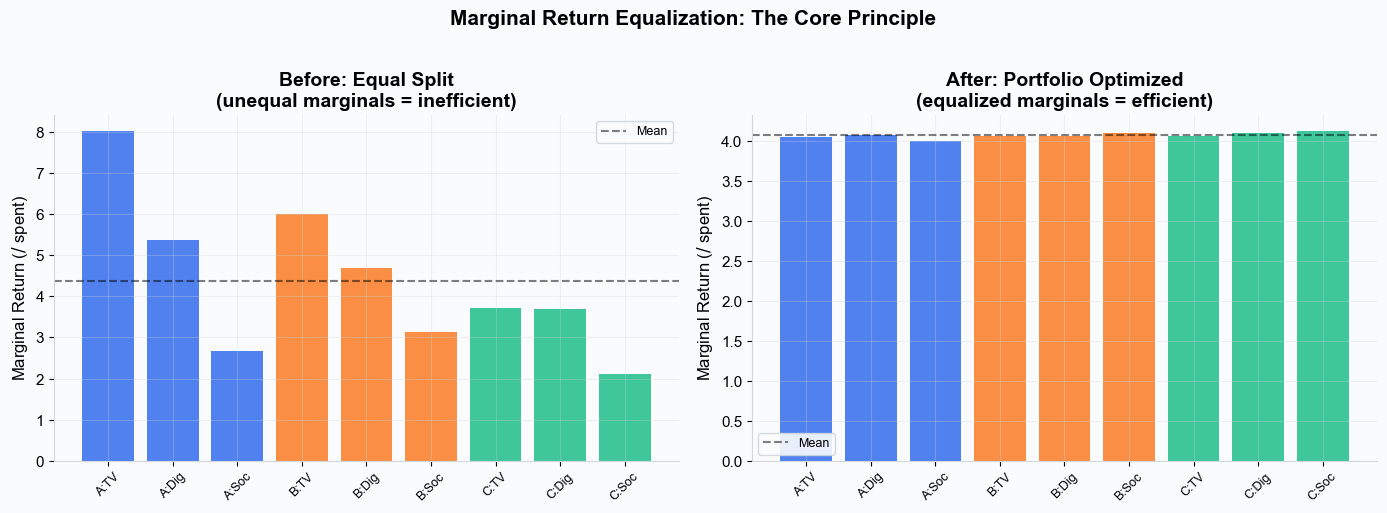

Before optimization: marginal returns vary widely (some channels over-funded, others under-funded).
After optimization: marginal returns converge — every dollar works equally hard.


In [19]:
# Marginal return comparison: before and after optimization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

keys = [(b, c) for b in BRANDS for c in CHANNELS]
labels = [f'{b[6]}:{c[:3]}' for b, c in keys]

# Equal split marginal returns
mr_equal = [marginal_response(TOTAL_BUDGET/9, *PARAMS[k]) for k in keys]
bar_colors = [COLORS[BRANDS.index(b)] for b, c in keys]

ax1.bar(range(len(keys)), mr_equal, color=bar_colors, alpha=0.8)
ax1.axhline(y=np.mean(mr_equal), color='black', linestyle='--', alpha=0.5, label='Mean')
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=45, fontsize=9)
ax1.set_ylabel('Marginal Return ($/$ spent)')
ax1.set_title('Before: Equal Split\n(unequal marginals = inefficient)')
ax1.legend(fontsize=9)

# Portfolio optimal marginal returns
mr_portfolio = [marginal_response(allocs_unconstrained[k], *PARAMS[k]) for k in keys]

ax2.bar(range(len(keys)), mr_portfolio, color=bar_colors, alpha=0.8)
ax2.axhline(y=np.mean(mr_portfolio), color='black', linestyle='--', alpha=0.5, label='Mean')
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=45, fontsize=9)
ax2.set_ylabel('Marginal Return ($/$ spent)')
ax2.set_title('After: Portfolio Optimized\n(equalized marginals = efficient)')
ax2.legend(fontsize=9)

plt.suptitle('Marginal Return Equalization: The Core Principle',
             fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/04_marginal_equalization.png', dpi=180, bbox_inches='tight')
plt.show()
print('Before optimization: marginal returns vary widely (some channels over-funded, others under-funded).')
print('After optimization: marginal returns converge \u2014 every dollar works equally hard.')

---

## 10. Using Real Data: From Model Output to Optimization

In practice, the response curve parameters ($\beta$, $\alpha$, scalar) come from your fitted MMM. Here's how to bridge the gap using the sample multi-brand dataset.

In [20]:
# Show the sample data structure
print('Sample multi-brand dataset:')
print(df.head(10).to_string(index=False))
print()

# Summarize by brand
spend_cols = ['tv_spend', 'digital_spend', 'social_spend']
brand_summary = df.groupby('brand').agg(
    weeks=('date', 'count'),
    mean_revenue=('revenue', 'mean'),
    total_tv=('tv_spend', 'sum'),
    total_digital=('digital_spend', 'sum'),
    total_social=('social_spend', 'sum'),
).round(0)

brand_summary['total_spend'] = brand_summary[['total_tv', 'total_digital', 'total_social']].sum(axis=1)
print('Brand summary:')
print(brand_summary.to_string())
print()
print('To use with the optimizer:')
print('  1. Fit an MMM per brand (or one model with brand effects) using PyMC-Marketing')
print('  2. Extract posterior means for beta (coefficient), alpha (saturation), and scalar (max spend)')
print('  3. Pass these parameters into the portfolio optimizer above')
print('  4. Set total_budget to your planning period budget')
print('  5. Add bounds_dict for any operational constraints')

Sample multi-brand dataset:
      date  brand   revenue  tv_spend  digital_spend  social_spend
2023-06-05 BrandA 509112.09  22565.84       10147.50       7589.66
2023-06-12 BrandA 520589.21  22909.74        6007.23      12812.34
2023-06-19 BrandA 536233.63   7704.35       43265.08       5241.87
2023-06-26 BrandA 522380.59      0.00       20811.75       4817.68
2023-07-03 BrandA 529144.29  13007.64       14922.53       5852.61
2023-07-10 BrandA 520908.91      0.00       12511.65      12519.39
2023-07-17 BrandA 539566.04  21688.91       29773.17      13114.62
2023-07-24 BrandA 529887.02  38283.07       21478.59      11151.90
2023-07-31 BrandA 525244.97  14975.73       15042.75      13394.12
2023-08-07 BrandA 548072.30  49358.02       16017.12       7171.87

Brand summary:
        weeks  mean_revenue   total_tv  total_digital  total_social  total_spend
brand                                                                           
BrandA     78      523711.0  1660728.0      1141556.0    

---

## Summary

### Key takeaways:

1. **PyMC-Marketing's `BudgetOptimizer`** handles single-model optimization using the full posterior distribution — use it as your first tool
2. **Independent optimization is suboptimal** — it can't shift budget between brands even when marginal returns differ
3. **Portfolio optimization equalizes marginal returns** across all brands and channels simultaneously
4. **Risk adjustment (γ)** lets you trade off expected revenue for diversification
5. **Trademark spillover** makes cross-brand channels more valuable than they appear in isolation
6. **Channel constraints** impose a modest cost but are necessary for operational feasibility

### When to use what:

| Scenario | Tool |
|---|---|
| Single brand, single model | **`BudgetOptimizer`** from PyMC-Marketing |
| Multiple brands, shared budget | **Portfolio optimizer** (this notebook's custom code) |
| Cross-brand spillover | **Portfolio optimizer** with trademark ghost curves |
| Risk-adjusted allocation | **Portfolio optimizer** with γ parameter |

---

## Next Steps

**Related notebooks:**
- [Notebook 01: Data Quality Checklist](01-data-quality-checklist.ipynb) — clean data is prerequisite to good models
- [Notebook 02: Smart Priors from Data](02-smart-priors-from-data.ipynb) — generate priors for the response curve parameters

**Core concepts:**
- [Saturation Curves](../docs/core-concepts/saturation-curves.md) — how tanh saturation works
- [Budget Optimization](../docs/core-concepts/budget-optimization.md) — optimization theory and the efficient frontier
- [Halo Effects](../docs/core-concepts/halo-effects.md) — cross-brand and cross-channel spillover
- [Bayesian Modeling](../docs/core-concepts/bayesian-modeling.md) — posterior distributions as optimizer inputs

**Platform guide:**
- [Budget Optimization](../docs/platform-guide/budget-optimization.md) — using the Simba optimizer UI
- [Portfolio Analysis](../docs/platform-guide/portfolio-analysis.md) — multi-brand analysis in Simba
